## ECG analysis steps

The goal of this project is to load, check and visualize ECG data.

The main steps are:
1. Load the raw ECG data.
2. Check that the data were loaded correctly.
3. Plot the raw ECG signal.
4. Rescale the ECG data to standard units.
5. Plot the rescaled ECG signal.
6. Improve the code to make it clearer and easier to reuse.

In [14]:
import numpy as np 
import matplotlib.pyplot as plt


In [15]:
raw_ecg = np.loadtxt("data/ECGu.txt")

In [16]:
print(raw_ecg)
print(raw_ecg.shape)

[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


## Plot the raw ECG data

The next step is to visualize the raw ECG signals. This allows us to visually inspect the signals before rescaling or further processing them.

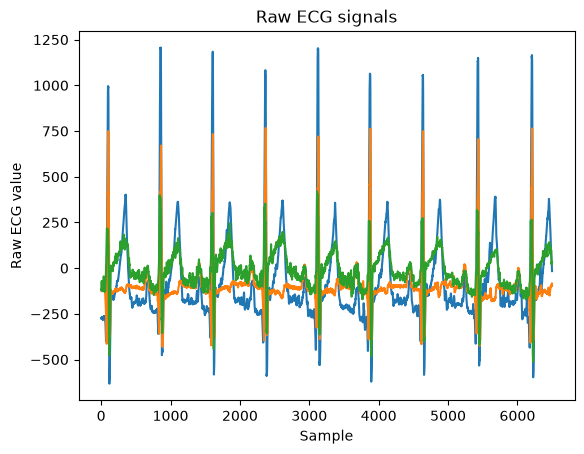

In [17]:
plt.plot(raw_ecg)

plt.xlabel("Sample")
plt.ylabel("Raw ECG value")
plt.title("Raw ECG signals")

plt.show()

### Check of the raw ECG plot

The plot appears to be correct because the three columns of the raw ECG data are displayed as three signals over the 6500 samples. The signals show repeated peaks and patterns, and their values are consistent with the raw data loaded from the file.

## Rescale the ECG data

The raw ECG values need to be converted into standard units before further analysis.

According to the recording equipment information:
- The sampling frequency is 1000 Hz.
- The A/D converter gain is 1024 µV per unit.

The ECG amplitude will be converted to millivolts, and a time axis in seconds will be created using the sampling frequency.

In [18]:
#Convert raw ECG values to millivots 
gain_uv = 1024

ecg_mv = raw_ecg / 1000

In [19]:
# Check the rescaled ECG data
print(ecg_mv)
print(ecg_mv.shape)

[[-0.275 -0.119 -0.119]
 [-0.275 -0.119 -0.119]
 [-0.275 -0.118 -0.121]
 ...
 [-0.004 -0.083  0.021]
 [-0.009 -0.088  0.031]
 [-0.016 -0.096  0.033]]
(6500, 3)


In [20]:
# Create a time axis in seconds using the sampling frequency
sampling_frequency = 1000

time_seconds = np.arange(raw_ecg.shape[0]) / sampling_frequency

In [21]:
# Check the time axis
print(time_seconds[:10])
print(time_seconds.shape)
print(time_seconds[-1])

[0.    0.001 0.002 0.003 0.004 0.005 0.006 0.007 0.008 0.009]
(6500,)
6.499


## Plot the rescaled ECG data

The ECG signals are now expressed in millivolts, and the time axis is expressed in seconds. We can use these variables to plot the ECG signals with meaningful units.

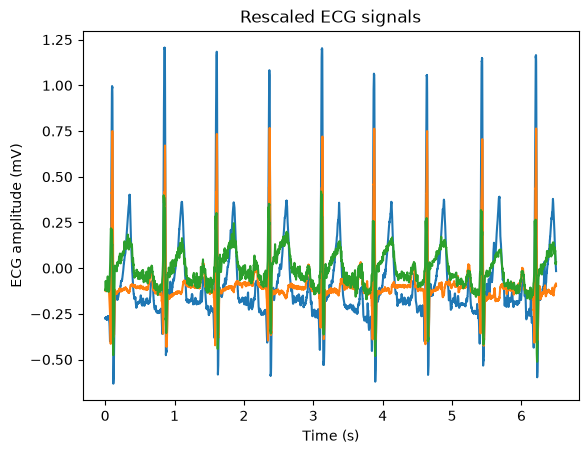

In [22]:
# Plot the rescaled ECG signals
plt.plot(time_seconds, ecg_mv)

plt.xlabel("Time (s)")
plt.ylabel("ECG amplitude (mV)")
plt.title("Rescaled ECG signals")

plt.show()

## Check the rescaled ECG plot

The rescaled ECG plot appears to be correct for several reasons.

- There are three time series, corresponding to the three recorded ECG leads: I, II and III.
- Each signal contains 6500 samples.
- The sampling frequency is 1000 Hz, so 6500 samples correspond to 6.5 seconds of recording.
- The ECG amplitudes are approximately between -0.6 mV and 1.2 mV, which is consistent with the millivolt scale normally used for ECG recordings. Standard ECG recordings are conventionally calibrated so that 1 mV corresponds to 10 mm.
- The signals show repeated ECG complexes over time, which is consistent with a periodic cardiac signal.

Additional checks could include verifying that the time interval between samples is 0.001 s and checking whether the three leads show cardiac events at approximately the same times, because they were recorded simultaneously.

Reference:
https://pmc.ncbi.nlm.nih.gov/articles/PMC5137383/

### Improve the plotting code

The plotting code is placed in a function to make its purpose clearer and to avoid repeating plotting instructions. The function performs one specific task: plotting ECG signals with appropriate axis labels and a title.

In [26]:
def plot_ecg(time, ecg_data, title):
    """Plot ECG signals as a function of time."""
    plt.plot(time, ecg_data)
    plt.xlabel("Time (s)")
    plt.ylabel("ECG amplitude (mV)")
    plt.title(title)
    plt.show()

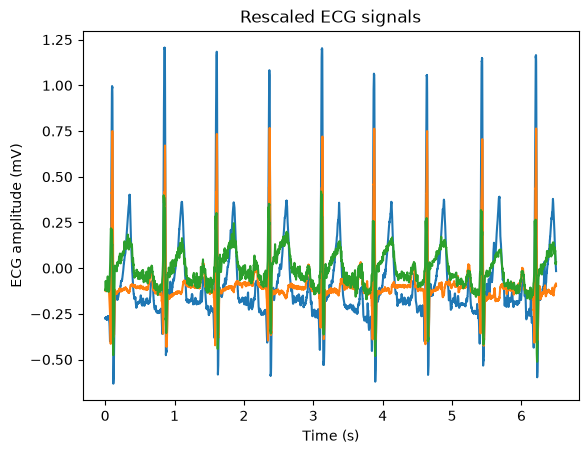

In [27]:
plot_ecg(time_seconds, ecg_mv, "Rescaled ECG signals")

## Realistic ECG plot

The goal is to display the three ECG leads in separate subplots and reproduce the appearance of a classical ECG recording.

The implementation will be divided into several functions:

1. `plot_grid()` creates a grid with specified time and voltage intervals.
2. `plot_ecg_grid()` creates the classical ECG major and minor grid.
3. `plot_one_ecg_signal()` plots one ECG lead.
4. `plot_one_lead_in_subplots()` combines one signal and the ECG grid in a subplot.
5. `plot_all_leads_in_subplots()` displays Leads I, II and III in separate subplots.

Dividing the task into functions makes the code easier to understand, test and improve.

### Create the ECG grid

The first function creates a grid with customizable time and voltage intervals. This basic function will later be reused to create the major and minor lines of a classical ECG grid.

In [29]:
def plot_grid(seconds_per_square, mV_per_square, alpha,
              min_time, max_time, min_ecg, max_ecg):
    """Plot a grid on the current Matplotlib axes."""
    
    vertical_lines = np.arange(
        min_time, max_time + seconds_per_square, seconds_per_square
    )
    
    horizontal_lines = np.arange(
        min_ecg, max_ecg + mV_per_square, mV_per_square
    )
    
    for x in vertical_lines:
        plt.axvline(x=x, alpha=alpha)
    
    for y in horizontal_lines:
        plt.axhline(y=y, alpha=alpha)

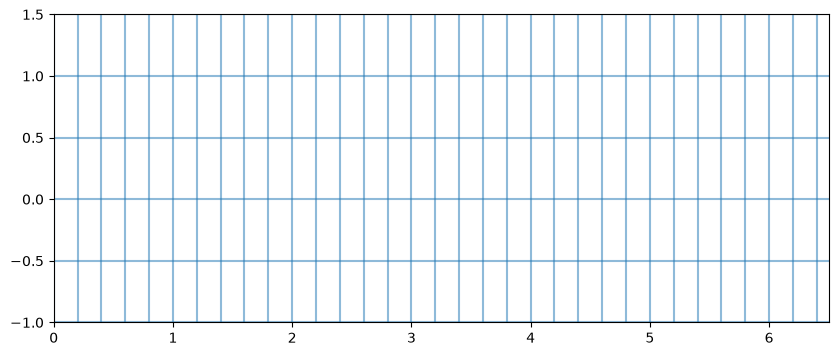

In [30]:
plt.figure(figsize=(10, 4))

plot_grid(
    seconds_per_square=0.2,
    mV_per_square=0.5,
    alpha=0.5,
    min_time=0,
    max_time=6.5,
    min_ecg=-1,
    max_ecg=1.5
)

plt.xlim(0, 6.5)
plt.ylim(-1, 1.5)
plt.show()

### Create a classical ECG grid

A classical ECG grid contains major and minor squares. Major grid lines are placed every 0.2 seconds and 0.5 mV. Minor grid lines are placed at one fifth of these intervals, corresponding to 0.04 seconds and 0.1 mV.

In [31]:
def plot_ecg_grid(min_time, max_time, min_ecg, max_ecg):
    """Plot a classical ECG grid using major and minor grid lines."""

    # Minor grid
    plot_grid(
        seconds_per_square=0.04,
        mV_per_square=0.1,
        alpha=0.2,
        min_time=min_time,
        max_time=max_time,
        min_ecg=min_ecg,
        max_ecg=max_ecg
    )

    # Major grid
    plot_grid(
        seconds_per_square=0.2,
        mV_per_square=0.5,
        alpha=0.5,
        min_time=min_time,
        max_time=max_time,
        min_ecg=min_ecg,
        max_ecg=max_ecg
    )

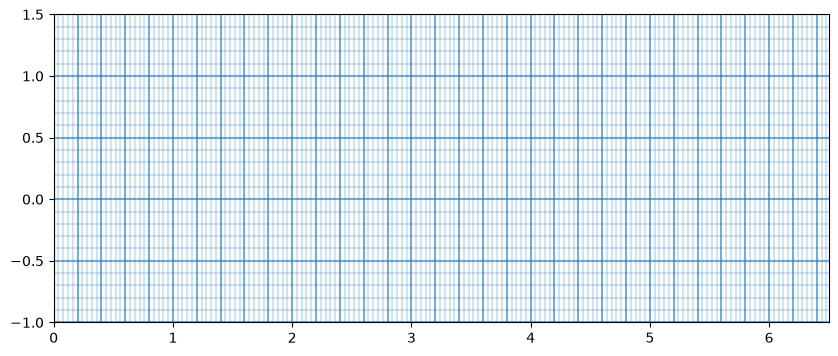

In [32]:
plt.figure(figsize=(10, 4))

plot_ecg_grid(
    min_time=0,
    max_time=6.5,
    min_ecg=-1,
    max_ecg=1.5
)

plt.xlim(0, 6.5)
plt.ylim(-1, 1.5)
plt.show()

In [34]:
def plot_one_ecg_signal(time, ecg, lead_name, color):
    """Plot one ECG lead on the current Matplotlib axes."""
    plt.plot(time, ecg, color=color)
    plt.title(lead_name)
    plt.xlabel("Time (s)")
    plt.ylabel("ECG amplitude (mV)")

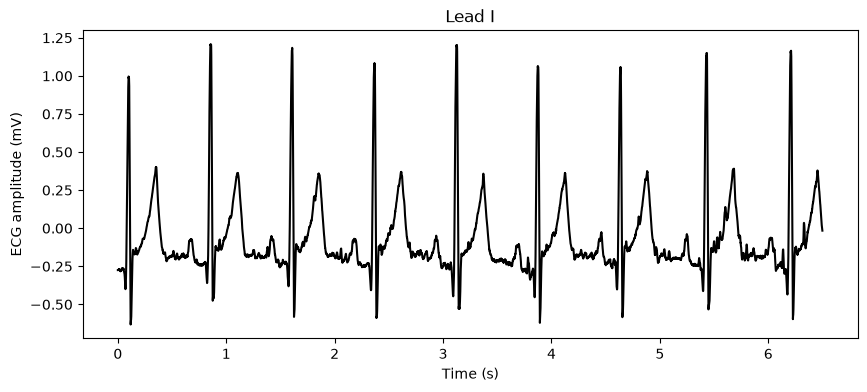

In [35]:
plt.figure(figsize=(10, 4))

plot_one_ecg_signal(
    time_seconds,
    ecg_mv[:, 0],
    "Lead I",
    "black"
)

plt.show()

In [36]:
def plot_one_lead_in_subplots(subplot, time, ecg, lead_name, color):
    """Plot one ECG lead with a classical ECG grid in a subplot."""

    plt.subplot(3, 1, subplot)

    plot_ecg_grid(
        min_time=time.min(),
        max_time=time.max(),
        min_ecg=-1,
        max_ecg=1.5
    )

    plot_one_ecg_signal(
        time,
        ecg,
        lead_name,
        color
    )

    plt.xlim(time.min(), time.max())
    plt.ylim(-1, 1.5)

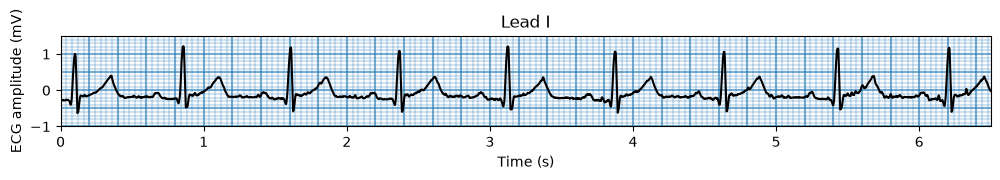

In [37]:
plt.figure(figsize=(12, 4))

plot_one_lead_in_subplots(
    1,
    time_seconds,
    ecg_mv[:, 0],
    "Lead I",
    "black"
)

plt.show()

### Plot all ECG leads

The final function combines the previous functions to display the three ECG leads in separate subplots. Each lead uses the same time and voltage scales and the classical ECG grid.

In [38]:
def plot_all_leads_in_subplots(time, ecg, lead_names, colors):
    """Plot all ECG leads in separate subplots with classical ECG grids."""

    plt.figure(figsize=(12, 9))

    for lead_index in range(3):
        plot_one_lead_in_subplots(
            lead_index + 1,
            time,
            ecg[:, lead_index],
            lead_names[lead_index],
            colors[lead_index]
        )

    plt.tight_layout()
    plt.show()

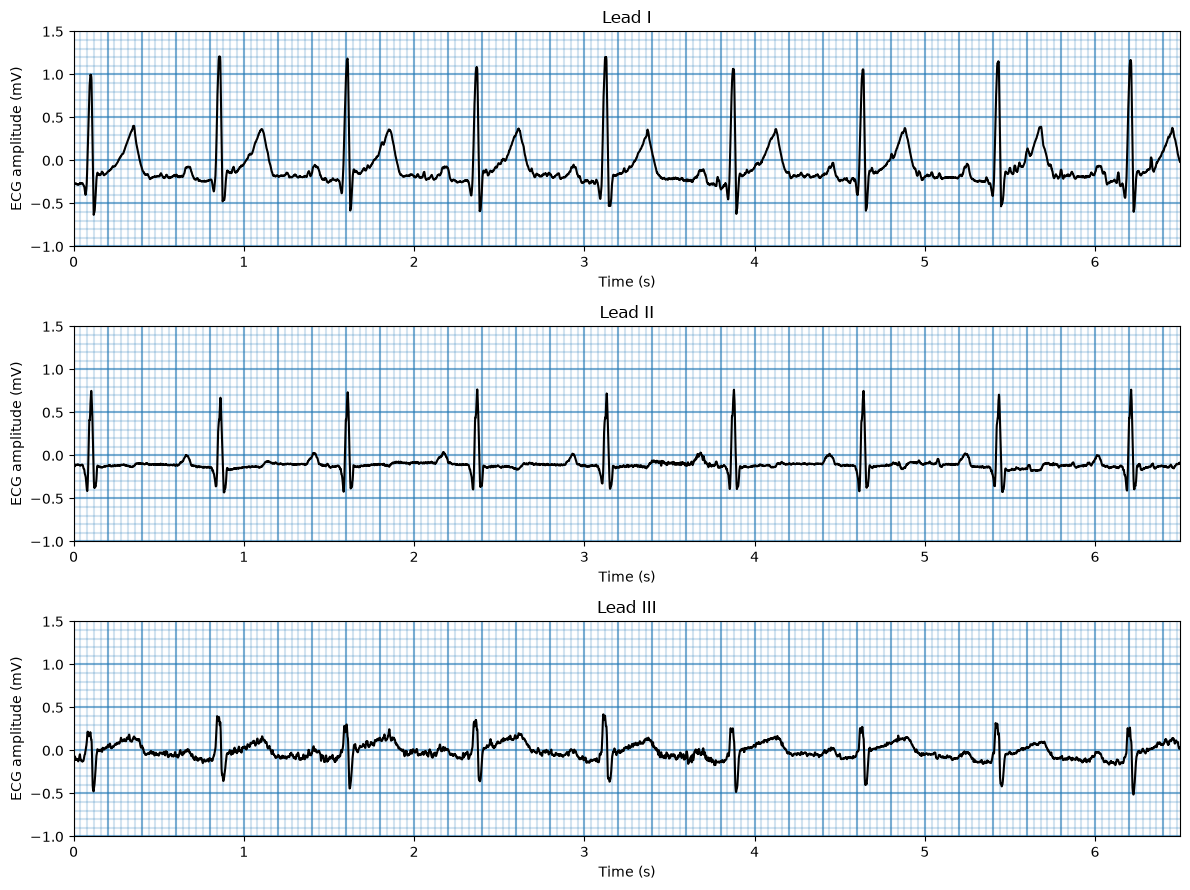

In [39]:
lead_names = ["Lead I", "Lead II", "Lead III"]
colors = ["black", "black", "black"]

plot_all_leads_in_subplots(
    time_seconds,
    ecg_mv,
    lead_names,
    colors
)

### Reference

The ECG display was inspired by the classical ECG representation shown by ECG Library:

https://ecglibrary.com/norm.php